<a href="https://colab.research.google.com/github/nurmiftakhul21-cyber/UTS_PCD/blob/main/UTS_PCD_NO(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan upload gambar untuk pengujian Filter Konvolusi:


Saving istockphoto-686219438-612x612.jpg to istockphoto-686219438-612x612.jpg


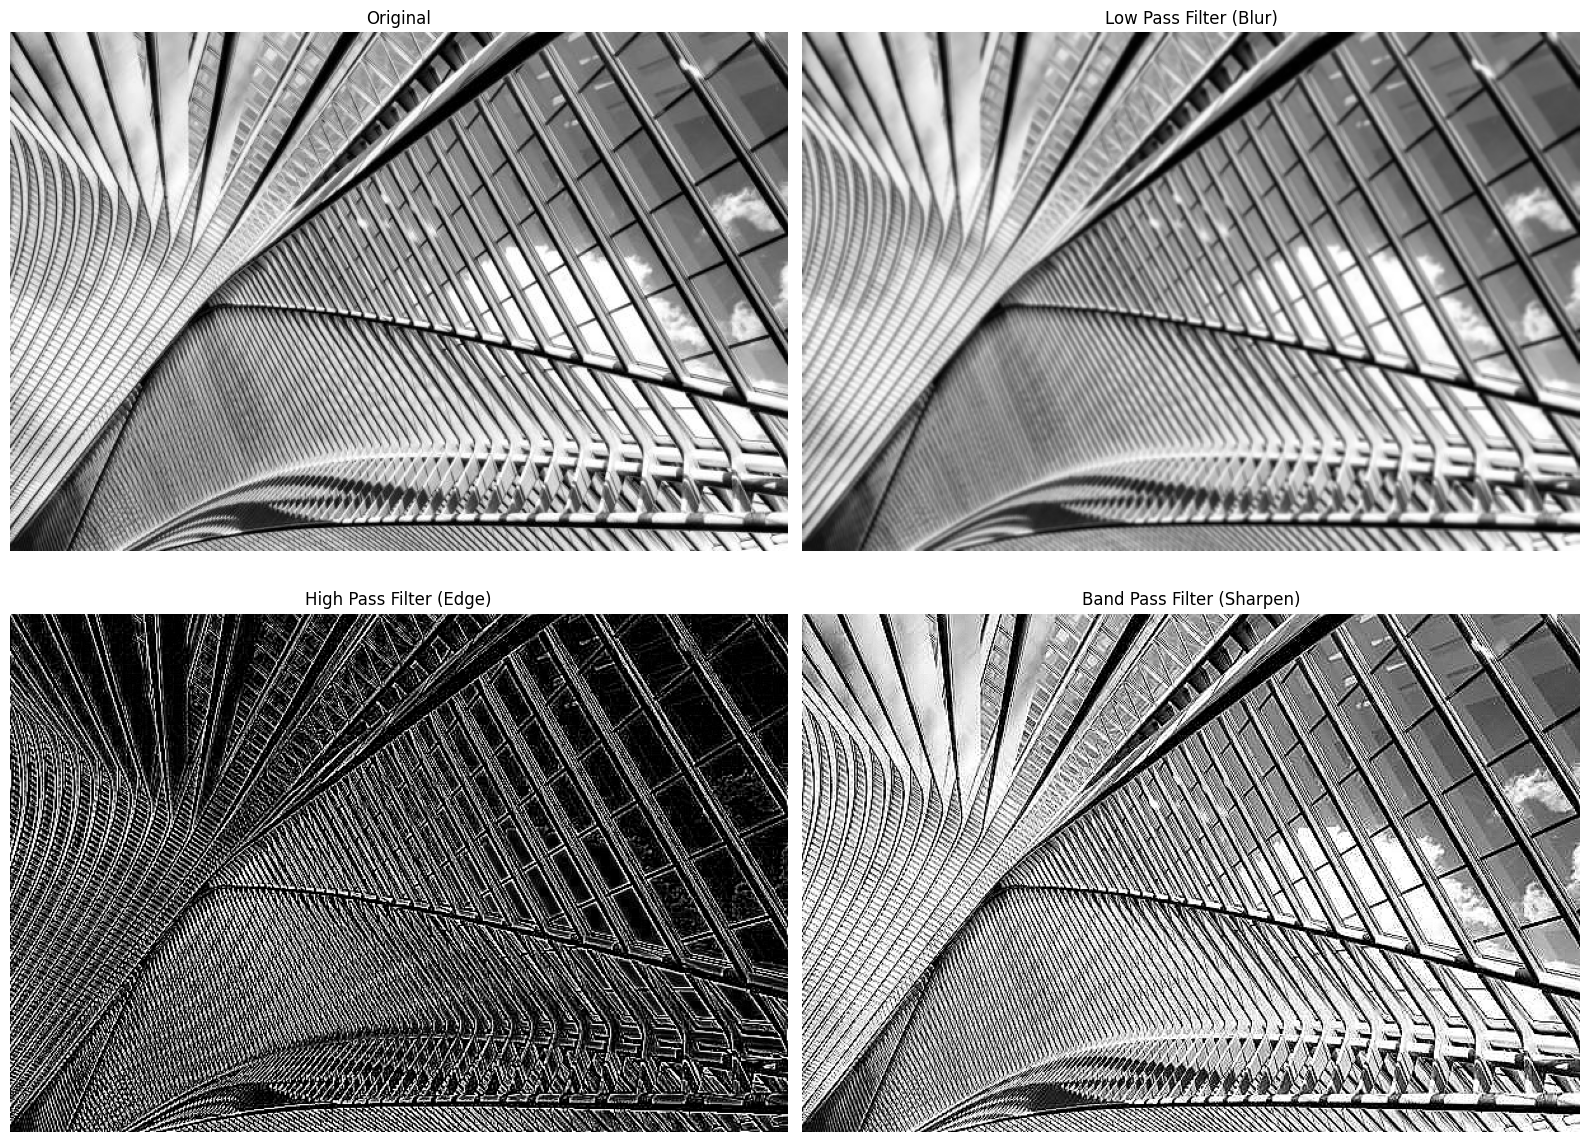

------------------------------
ANALISA NILAI PIKSEL RATA-RATA:
Rata-rata Original : 148.84
Rata-rata LPF      : 148.85
Rata-rata HPF      : 64.42
Rata-rata BPF      : 148.69
------------------------------


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. PROSES UPLOAD GAMBAR (Karena ini notebook baru)
print("Silakan upload gambar untuk pengujian Filter Konvolusi:")
uploaded = files.upload()

for fn in uploaded.keys():
    img_asli = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)

    if img_asli is not None:
        # 2. DEFINISI KERNEL SESUAI SOAL

        # Low Pass Filter (LPF) - Tujuan: Reduksi noise / blur
        kernel_lpf = np.ones((3, 3), np.float32) / 9

        # High Pass Filter (HPF) - Tujuan: Deteksi tepi
        kernel_hpf = np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]])

        # Band Pass Filter (BPF) - Tujuan: Penajaman (sharpening)
        kernel_bpf = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]])

        # 3. TERAPKAN KONVOLUSI
        # Menggunakan cv2.filter2D dengan ddepth -1 (kedalaman yang sama dengan asli)
        img_lpf = cv2.filter2D(img_asli, -1, kernel_lpf)
        img_hpf = cv2.filter2D(img_asli, -1, kernel_hpf)
        img_bpf = cv2.filter2D(img_asli, -1, kernel_bpf)

        # 4. TAMPILKAN HASIL (4 GAMBAR DALAM SATU FIGURE)
        plt.figure(figsize=(16, 12))

        titles = ['Original', 'Low Pass Filter (Blur)', 'High Pass Filter (Edge)', 'Band Pass Filter (Sharpen)']
        images = [img_asli, img_lpf, img_hpf, img_bpf]

        for i in range(4):
            plt.subplot(2, 2, i+1)
            plt.imshow(images[i], cmap='gray')
            plt.title(titles[i])
            plt.axis('off')

        plt.tight_layout()
        plt.show()

        # 5. NILAI PIKSEL RATA-RATA (UNTUK BAHAN ANALISA)
        print("-" * 30)
        print(f"ANALISA NILAI PIKSEL RATA-RATA:")
        print(f"Rata-rata Original : {np.mean(img_asli):.2f}")
        print(f"Rata-rata LPF      : {np.mean(img_lpf):.2f}")
        print(f"Rata-rata HPF      : {np.mean(img_hpf):.2f}")
        print(f"Rata-rata BPF      : {np.mean(img_bpf):.2f}")
        print("-" * 30)

    else:
        print("Gagal membaca gambar. Pastikan file yang diunggah valid.")